# WHO Life Expectancy: Full EDA + Linear Regression Insights

**What drives how long people live?** This notebook explores 16 years (2000–2015) of WHO/UN
data covering 193 countries, looking at how mortality, immunization, economic development,
and education relate to life expectancy — then builds a simple, interpretable linear
regression model to quantify those relationships.

**Why this notebook is a little different:** my background is in mathematical epidemiology
(compartmental disease models, fractional-order systems), so throughout this analysis I pay
extra attention to the *mortality and disease* features (Adult Mortality, HIV/AIDS, immunization
coverage) rather than treating them as just another column in a regression table.

### Contents
1. [Data Loading & First Look](#load)
2. [Data Cleaning](#clean)
3. [Univariate Analysis](#univariate)
4. [Developed vs Developing Countries](#status)
5. [Trends Over Time](#trends)
6. [Correlation Analysis](#corr)
7. [Key Relationships (Bivariate)](#bivariate)
8. [Which Countries Stand Out?](#extremes)
9. [Predictive Modeling — Linear Regression](#model)
10. [Key Insights & Conclusion](#insights)

**Data source:** [Life Expectancy (WHO)](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who),
compiled from the WHO Global Health Observatory and UN data repositories by Deeksha Russell and Duan Wang.


## 1. Data Loading & First Look <a id='load'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 25)


In [2]:
import os

kaggle_path = "/kaggle/input/life-expectancy-who/Life Expectancy Data.csv"
local_path = "Life Expectancy Data.csv"

df = pd.read_csv(kaggle_path if os.path.exists(kaggle_path) else local_path)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 2,938 rows x 22 columns


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


The dataset has **2,938 rows** across **193 countries** and **16 years (2000–2015)**, with
22 columns spanning mortality, immunization, economic, and social factors.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

## 2. Data Cleaning <a id='clean'></a>

In [4]:
# Column names have inconsistent leading/trailing whitespace - standardize them
df.columns = [c.strip() for c in df.columns]
df.columns = df.columns.str.replace(r"\s+", " ", regex=True)
print(df.columns.tolist())


['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness 1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_table


,missing_count,missing_pct
Population,652,22.2
Hepatitis B,553,18.8
GDP,448,15.2
Total expenditure,226,7.7
Alcohol,194,6.6
Income composition of resources,167,5.7
Schooling,163,5.5
thinness 5-9 years,34,1.2
thinness 1-19 years,34,1.2
BMI,34,1.2


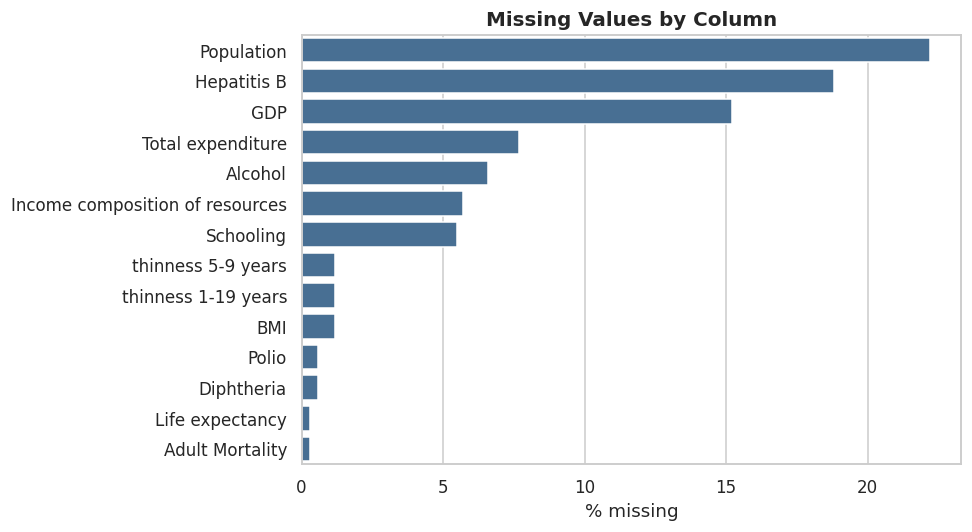

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=missing_table["missing_pct"], y=missing_table.index, color="#3b6fa0", ax=ax)
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Missing Values by Column")
plt.tight_layout()
plt.show()


**Population, Hepatitis B, and GDP** have the most missing data (15–22%), mostly from
smaller, less-tracked nations. Rather than dropping these countries outright, missing values
are imputed later (median, grouped by development `Status`) right before modeling — this
keeps the full dataset available for exploratory analysis.

In [7]:
# Drop the handful of rows with no target value at all - can't analyze life expectancy without it
df = df.dropna(subset=["Life expectancy"]).reset_index(drop=True)
print(f"Shape after dropping missing target rows: {df.shape}")


Shape after dropping missing target rows: (2928, 22)


## 3. Univariate Analysis <a id='univariate'></a>

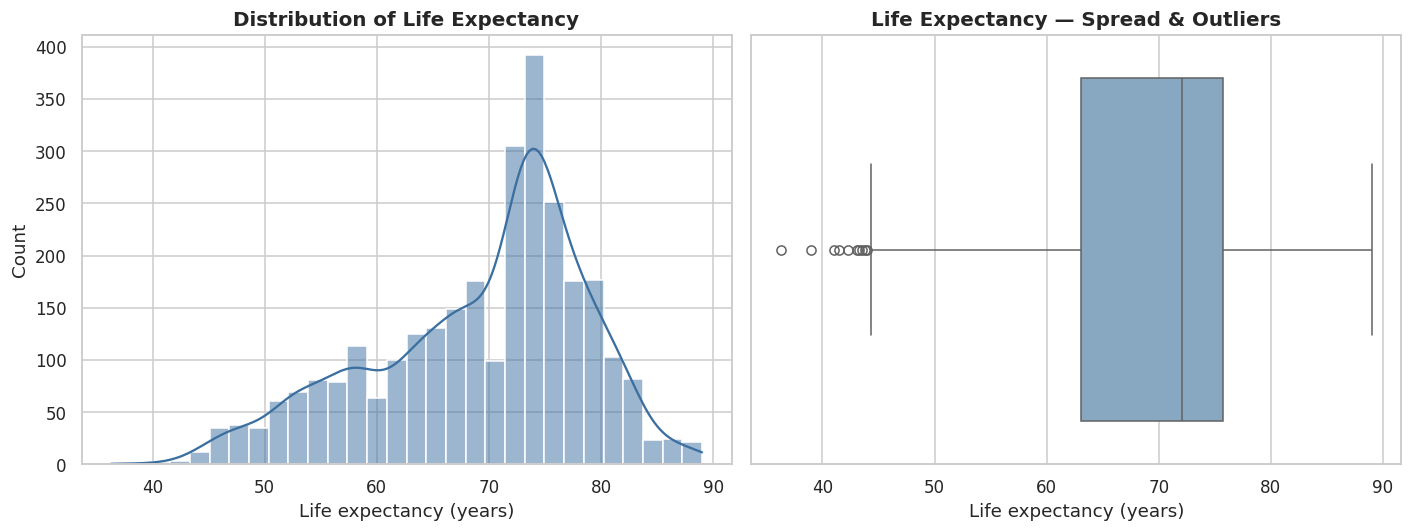

count    2928.0
mean       69.2
std         9.5
min        36.3
25%        63.1
50%        72.1
75%        75.7
max        89.0
Name: Life expectancy, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["Life expectancy"], bins=30, kde=True, color="#3b6fa0", ax=axes[0])
axes[0].set_title("Distribution of Life Expectancy")
axes[0].set_xlabel("Life expectancy (years)")

sns.boxplot(x=df["Life expectancy"], color="#7fa8c9", ax=axes[1])
axes[1].set_title("Life Expectancy — Spread & Outliers")
axes[1].set_xlabel("Life expectancy (years)")

plt.tight_layout()
plt.show()

print(df["Life expectancy"].describe().round(1))


Global life expectancy in this period averages around **69 years**, but the spread is wide
(roughly 44 to 89 years), and the distribution is slightly left-skewed — a cluster of
low-income countries pulls the lower tail down.

## 4. Developed vs Developing Countries <a id='status'></a>

/tmp/ipykernel_636/3341982229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Status", y="Life expectancy", palette=["#3b6fa0", "#d98c4a"], ax=ax)


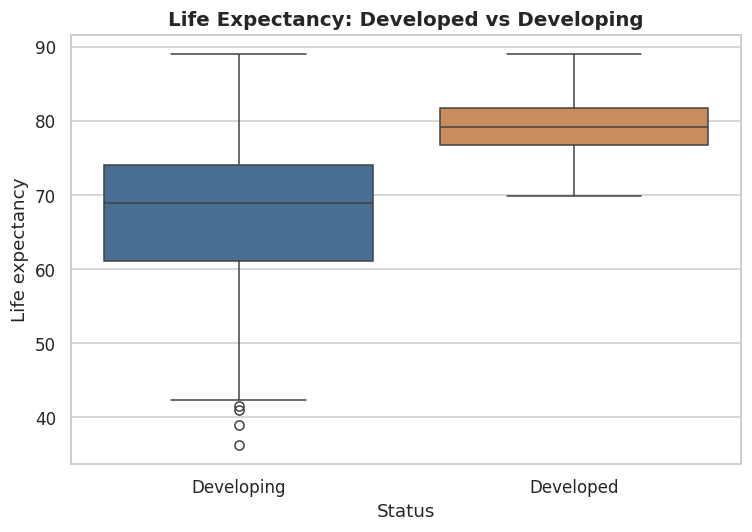

,mean,median,std,count
Status,,,,
Developed,79.20,79.25,3.93,512
Developing,67.11,69.00,9.01,2416


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Status", y="Life expectancy", palette=["#3b6fa0", "#d98c4a"], ax=ax)
ax.set_title("Life Expectancy: Developed vs Developing")
plt.tight_layout()
plt.show()

df.groupby("Status")["Life expectancy"].agg(["mean", "median", "std", "count"]).round(2)


Developed countries average roughly **10–12 years higher** life expectancy than developing
ones, with noticeably less variance — development status alone explains a meaningful chunk of
the spread we saw above.

## 5. Trends Over Time (2000–2015) <a id='trends'></a>

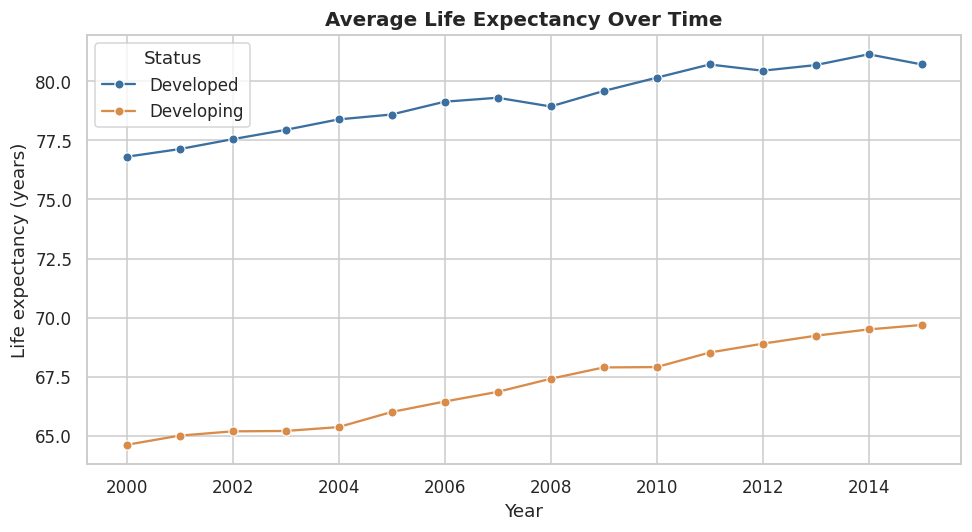

In [10]:
trend = df.groupby(["Year", "Status"])["Life expectancy"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=trend, x="Year", y="Life expectancy", hue="Status",
             marker="o", palette=["#3b6fa0", "#d98c4a"], ax=ax)
ax.set_title("Average Life Expectancy Over Time")
ax.set_ylabel("Life expectancy (years)")
plt.tight_layout()
plt.show()


Both groups trend **upward** over the 16-year window, and the gap between developed and
developing countries narrows slightly — consistent with global health and immunization gains,
though developing nations still lag by roughly a decade.

## 6. Correlation Analysis <a id='corr'></a>

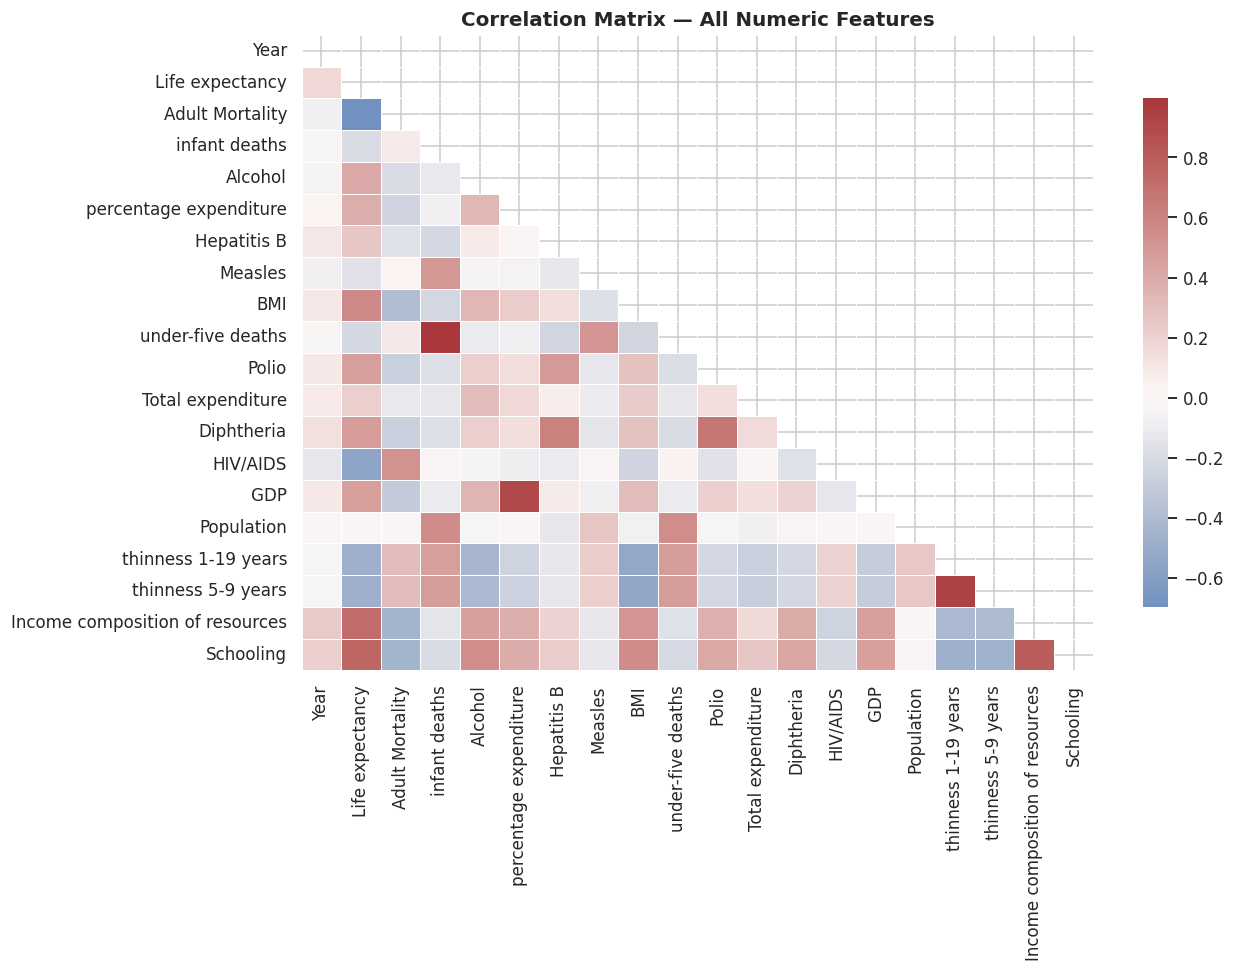

Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Year                               0.170033
Population                        -0.021538
Measles                           -0.157586
infant deaths                     -0.196557
under-five deaths                 -0.222529
thinness 5-9 years                -0.471584
thinness 1-19 years               -0.477183
HIV/AIDS                          -0.556556
Adult Mortality                   -0.696359
Name: Life expectancy, dtype: float64

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, annot=False,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix — All Numeric Features")
plt.tight_layout()
plt.show()

corr["Life expectancy"].drop("Life expectancy").sort_values(ascending=False)


The strongest correlations with life expectancy are:
- **Positive:** Schooling, Income composition of resources, BMI, Diphtheria/Polio immunization
- **Negative:** Adult Mortality (strongest, by far), HIV/AIDS, infant deaths, thinness in children

This matches domain expectations — mortality and immunization-related variables dominate, with
education and income acting as strong structural proxies.

## 7. Key Relationships (Bivariate) <a id='bivariate'></a>

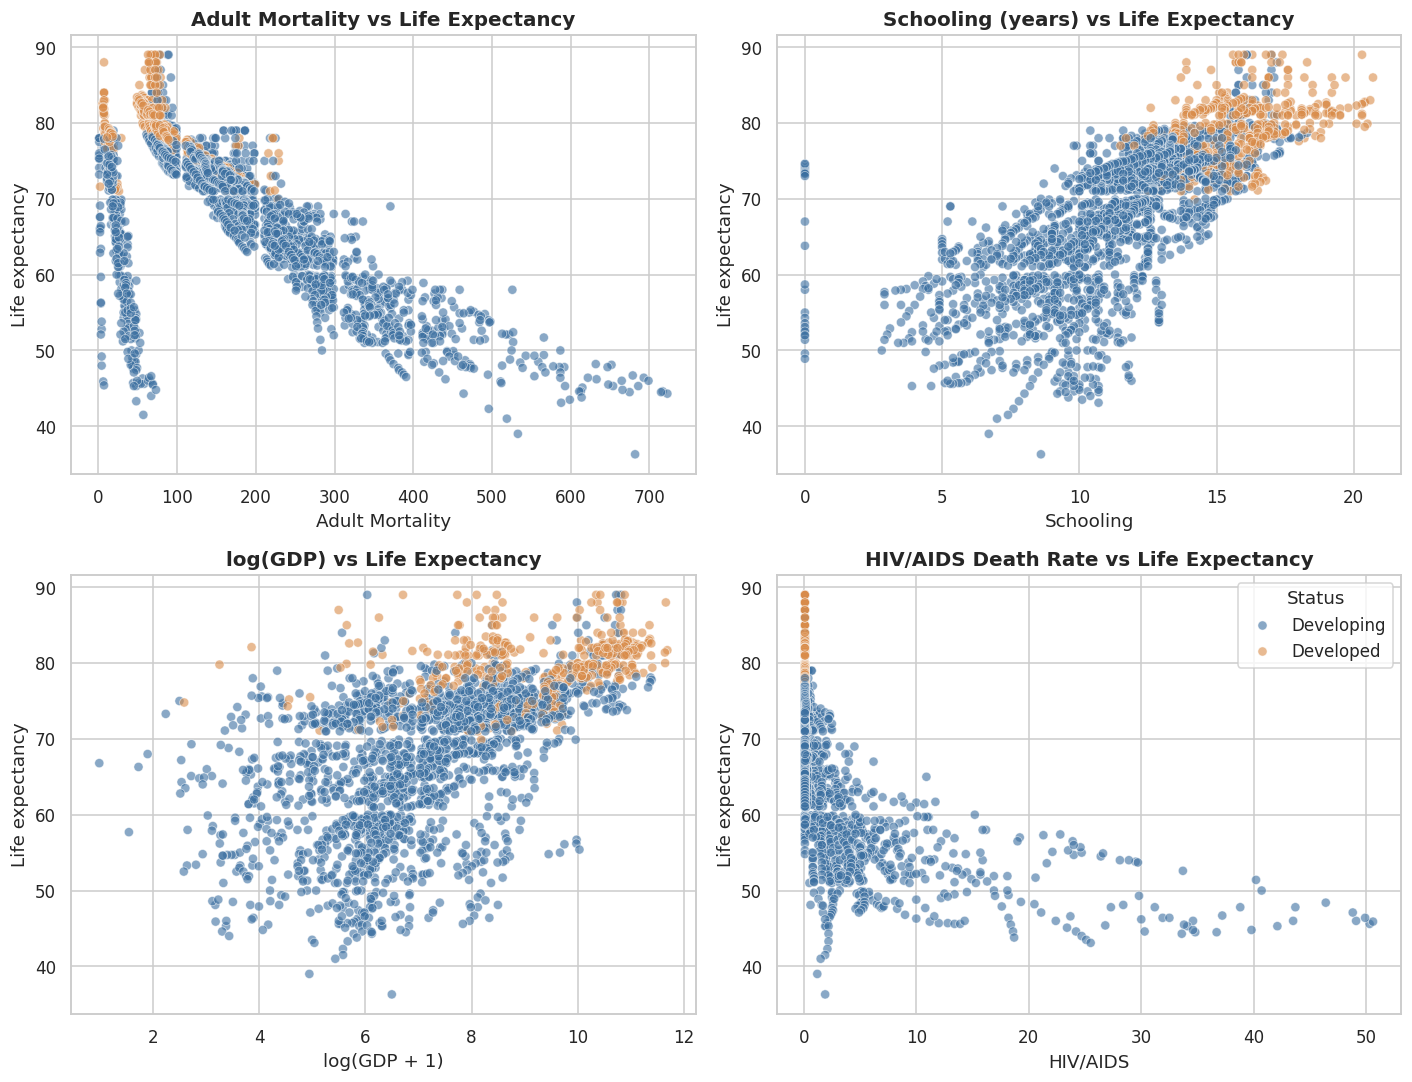

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.scatterplot(data=df, x="Adult Mortality", y="Life expectancy", hue="Status",
                 palette=["#3b6fa0", "#d98c4a"], alpha=0.6, ax=axes[0, 0], legend=False)
axes[0, 0].set_title("Adult Mortality vs Life Expectancy")

sns.scatterplot(data=df, x="Schooling", y="Life expectancy", hue="Status",
                 palette=["#3b6fa0", "#d98c4a"], alpha=0.6, ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Schooling (years) vs Life Expectancy")

df["GDP_log"] = np.log1p(df["GDP"])
sns.scatterplot(data=df, x="GDP_log", y="Life expectancy", hue="Status",
                 palette=["#3b6fa0", "#d98c4a"], alpha=0.6, ax=axes[1, 0], legend=False)
axes[1, 0].set_title("log(GDP) vs Life Expectancy")
axes[1, 0].set_xlabel("log(GDP + 1)")

sns.scatterplot(data=df, x="HIV/AIDS", y="Life expectancy", hue="Status",
                 palette=["#3b6fa0", "#d98c4a"], alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title("HIV/AIDS Death Rate vs Life Expectancy")
axes[1, 1].legend(title="Status", loc="upper right")

plt.tight_layout()
plt.show()


- **Adult Mortality** shows the cleanest, strongest negative relationship — almost linear.
- **Schooling** shows a clear positive trend, with a steeper slope at lower schooling levels.
- **GDP** (log-transformed to tame its skew) is positively associated, but with more scatter —
  money helps, but doesn't guarantee health outcomes on its own.
- **HIV/AIDS** death rate has a sharp negative effect concentrated in a subset of countries
  (mostly Sub-Saharan Africa in the early 2000s) rather than a smooth global trend.

## 8. Which Countries Stand Out? <a id='extremes'></a>

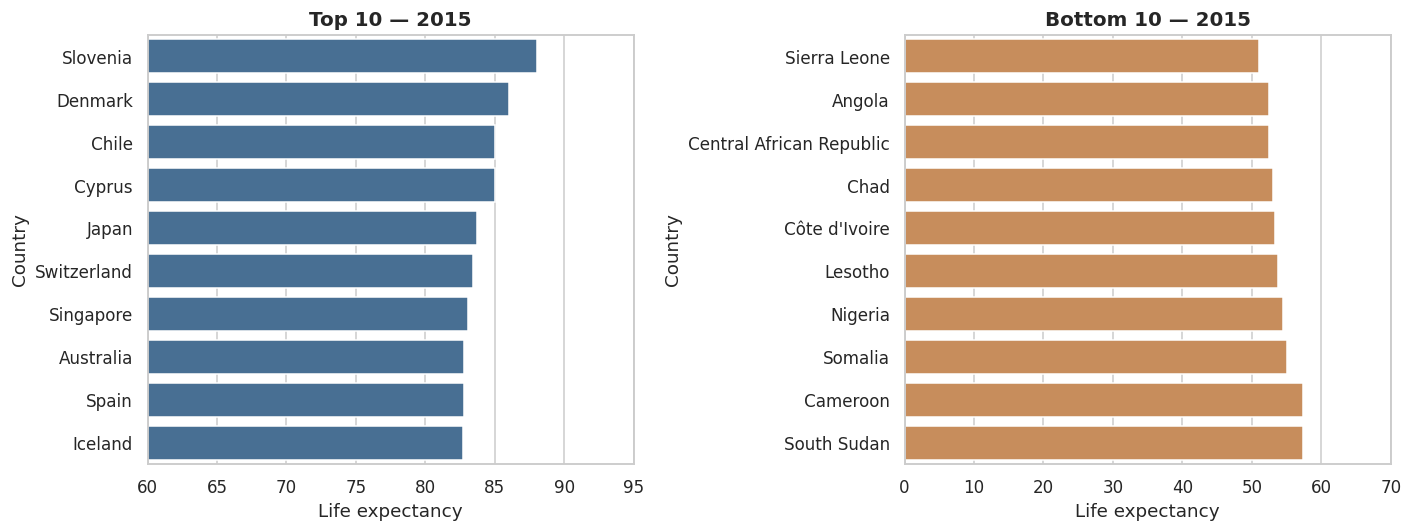

In [13]:
latest = df[df["Year"] == df["Year"].max()]
top10 = latest.nlargest(10, "Life expectancy")[["Country", "Life expectancy"]]
bottom10 = latest.nsmallest(10, "Life expectancy")[["Country", "Life expectancy"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=top10, x="Life expectancy", y="Country", color="#3b6fa0", ax=axes[0])
axes[0].set_title(f"Top 10 — {int(df['Year'].max())}")
axes[0].set_xlim(60, 95)

sns.barplot(data=bottom10, x="Life expectancy", y="Country", color="#d98c4a", ax=axes[1])
axes[1].set_title(f"Bottom 10 — {int(df['Year'].max())}")
axes[1].set_xlim(0, 70)

plt.tight_layout()
plt.show()


## 9. Predictive Modeling — Linear Regression <a id='model'></a>

To go beyond correlations, a multiple linear regression model is fitted to quantify how
much each factor contributes, holding the others constant. Missing values are imputed with the
**median within each development `Status` group** (developed countries shouldn't borrow
imputed values from developing-country medians, and vice versa).

In [14]:
model_df = df.drop(columns=["GDP_log"]).copy()

# Encode Status as a binary indicator
model_df["Status_Developed"] = (model_df["Status"] == "Developed").astype(int)

feature_cols = [
    "Adult Mortality", "infant deaths", "Alcohol", "percentage expenditure",
    "Hepatitis B", "Measles", "BMI", "under-five deaths", "Polio",
    "Total expenditure", "Diphtheria", "HIV/AIDS", "GDP", "Population",
    "thinness 1-19 years", "thinness 5-9 years",
    "Income composition of resources", "Schooling", "Status_Developed",
]

X = model_df[feature_cols].copy()
y = model_df["Life expectancy"].copy()

# Median imputation, grouped by development status
for col in X.columns:
    if X[col].isnull().any():
        X[col] = model_df.groupby("Status")[col].transform(lambda s: s.fillna(s.median()))
        X[col] = X[col].fillna(X[col].median())  # safety net for any still-missing group medians

print("Remaining missing values:", X.isnull().sum().sum())


Remaining missing values: 0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared : {r2:.3f}")
print(f"RMSE      : {rmse:.2f} years")
print(f"MAE       : {mae:.2f} years")


R-squared : 0.822
RMSE      : 3.92 years
MAE       : 2.91 years


The model explains a large majority of the variance in life expectancy from these 18
features alone, with an average prediction error of just a few years — solid performance for a
plain linear model with no interaction terms or regularization.

/tmp/ipykernel_636/2225943120.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_table, x="coefficient", y="feature", palette=colors, ax=ax)


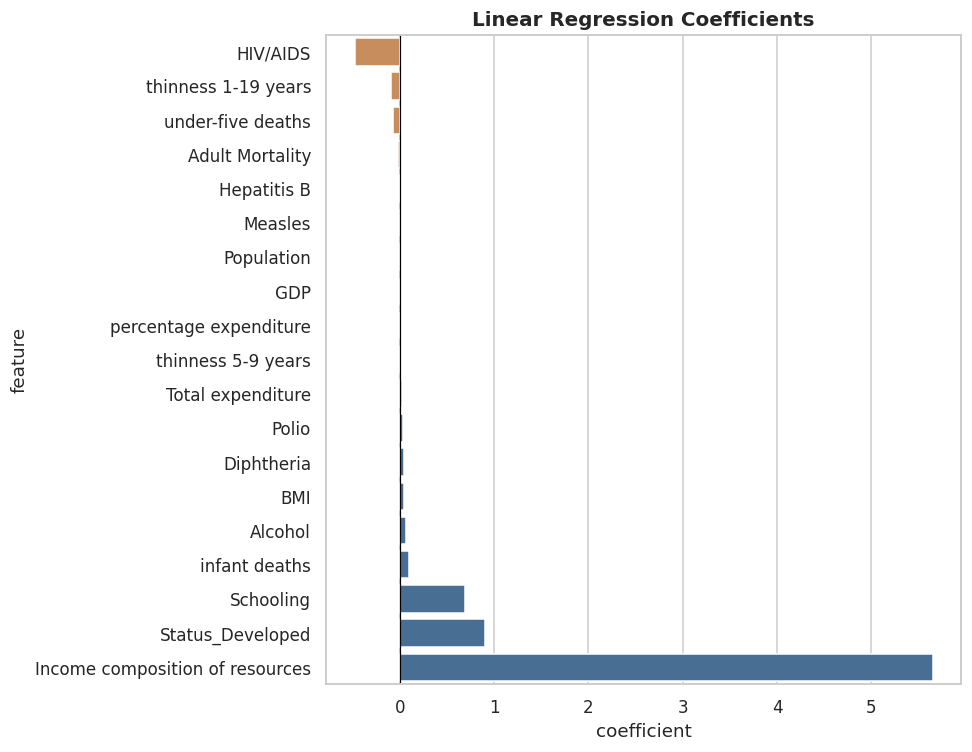

,feature,coefficient
16,Income composition of resources,5.649788e+00
18,Status_Developed,9.066040e-01
17,Schooling,6.884950e-01
1,infant deaths,9.619706e-02
2,Alcohol,6.823992e-02
6,BMI,3.856036e-02
10,Diphtheria,3.804425e-02
8,Polio,3.163278e-02
9,Total expenditure,2.069697e-02
15,thinness 5-9 years,2.020762e-03


In [16]:
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#d98c4a" if c < 0 else "#3b6fa0" for c in coef_table["coefficient"]]
sns.barplot(data=coef_table, x="coefficient", y="feature", palette=colors, ax=ax)
ax.set_title("Linear Regression Coefficients")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

coef_table.sort_values("coefficient", ascending=False)


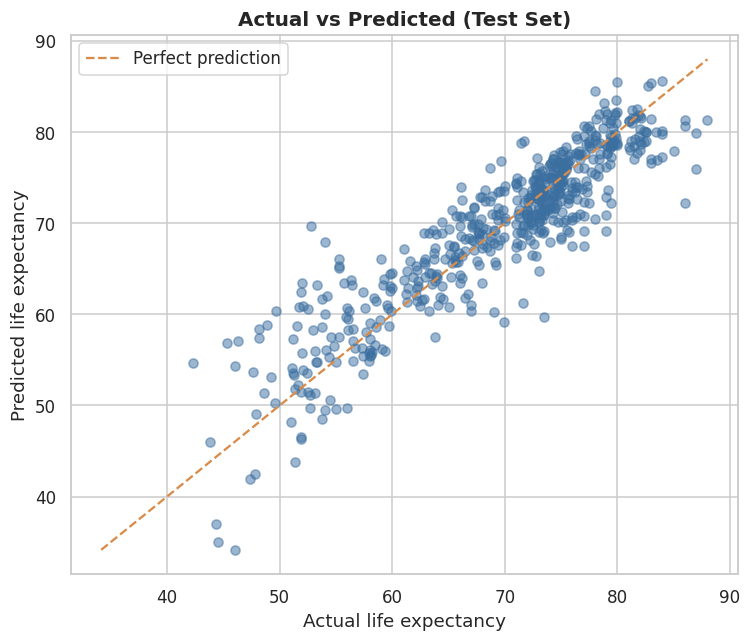

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color="#3b6fa0")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color="#d98c4a", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual life expectancy")
ax.set_ylabel("Predicted life expectancy")
ax.set_title("Actual vs Predicted (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()


Points cluster tightly around the diagonal, with a slight tendency to under-predict at the
very lowest life-expectancy values — these are typically countries facing acute crises (conflict,
epidemic outbreaks) where a linear, static-feature model can't fully capture the shock.

## 10. Key Insights & Conclusion <a id='insights'></a>

1. **Adult Mortality dominates.** It has both the strongest raw correlation and one of the
   largest regression coefficients — unsurprising, but it confirms mortality data quality should
   be the top priority for any country trying to track this metric well.
2. **Education and income are powerful structural levers.** Schooling and income composition
   show consistent positive effects, suggesting long-run investment in education pays
   off in population health, not just income.
3. **Disease-specific shocks matter locally, not globally.** HIV/AIDS' effect is concentrated
   in specific countries/years rather than a smooth worldwide trend — a reminder that global
   averages can mask severe regional crises.
4. **Money alone isn't the whole story.** GDP's relationship with life expectancy is positive but
   noisy — suggesting *how* health spending is allocated may matter more than the raw amount.
5. **Developed vs developing gap is narrowing but real.** Roughly a decade of life expectancy
   still separates the two groups as of 2015, even as both trend upward together.

**Possible next steps:** model the data as a genuine panel/time-series (countries observed
repeatedly across years) rather than pooling all rows, try non-linear models (Random Forest,
Gradient Boosting) to capture threshold effects, and bring in a compartmental epidemiological
lens for disease-driven mortality components specifically.

---
*If you found this useful, an upvote helps it reach more people — feedback and suggestions are very welcome in the comments.*
